# Chapter 5 — Hands-on SDR (optional)

!!! info "Before you start"
    **Prerequisites:** Ch 4 (Antennas & Receivers) · **Maths Lab:** none · **~40 min** · **Beginner** (optional hardware)

> **This chapter is OPTIONAL and hardware-flavoured.** It is the one place in the
> course where you *could* plug in a real **software-defined radio** (an RTL-SDR
> dongle) and capture live radio data. But you do **not** need any hardware to
> work through it: every cell here runs end-to-end on the plain `jansky` base
> environment using a **simulated IQ signal** built from NumPy. Wherever real
> hardware would appear, we guard the import in `try/except` and fall back to the
> simulation, and we leave two clearly marked `# TODO` exercises for when (or if)
> you get a dongle.

So far the course has treated the telescope back-end as an idealised box that
hands us temperatures and spectra ([Chapter 3](03_signals_noise_radiometer.ipynb))
collected by an antenna and receiver ([Chapter 4](04_antennas_and_receivers.ipynb)).
This chapter opens that box. A modern receiver does most of its work **in
software**: it samples the radio voltage directly, hands you a stream of complex
numbers, and lets *you* compute the spectrum. A \$30 USB dongle does exactly this,
and understanding it demystifies how *every* digital radio telescope works.

## What you'll learn

- What a **software-defined radio (SDR)** is, and what the cheap **RTL-SDR**
  dongle can and cannot do.
- **Sampling** and the **Nyquist–Shannon theorem**: why a sample rate $f_s$ lets
  you represent signals only up to $f_s/2$, and what **aliasing** does to the rest.
- What **IQ (complex baseband) data** is and why SDRs deliver it.
- How to turn a stream of IQ samples into a **power spectrum** with the FFT and,
  more robustly, the **Welch periodogram** (`scipy.signal.welch`).
- How to read a **waterfall / spectrogram** (`scipy.signal.spectrogram`) — the
  time–frequency view every SDR tool shows you.
- Where real hardware fits in: the **GNU Radio container**
  (`containers/gnuradio.Dockerfile`) that ships the drivers for live capture.

## The tools: RTL-SDR and GNU Radio

There is no single "paper" for software radio, but two project pages anchor this
chapter, plus the theorem that makes it all work.

> **RTL-SDR.** A whole community grew up around the discovery (≈2012) that certain
> cheap Realtek **RTL2832U** DVB-T (digital TV) USB tuners can be put into a raw
> sampling mode and used as a general-purpose receiver from roughly 24 MHz to
> 1.7 GHz. See the project / driver pages:
> [rtl-sdr.com](https://www.rtl-sdr.com/about-rtl-sdr/) and the **Osmocom**
> `rtl-sdr` driver, [osmocom.org/projects/rtl-sdr](https://osmocom.org/projects/rtl-sdr/wiki).
> The Python bindings used by real-hardware notebooks are **pyrtlsdr**
> ([github.com/pyrtlsdr/pyrtlsdr](https://github.com/pyrtlsdr/pyrtlsdr)).

> **GNU Radio.** The free signal-processing framework most SDR work is built on —
> a graph of DSP blocks you wire together. Project page:
> [gnuradio.org](https://www.gnuradio.org/). Our
> `containers/gnuradio.Dockerfile` installs GNU Radio + `gr-osmosdr` + `rtl-sdr`
> so you can talk to a real dongle without polluting the base environment.

> **The sampling theorem (Nyquist–Shannon).** Shannon, C. E. (1949),
> *Communication in the Presence of Noise*, Proc. IRE **37**(1), 10–21,
> [DOI: 10.1109/JRPROC.1949.232969](https://doi.org/10.1109/JRPROC.1949.232969),
> building on Nyquist (1928) and Whittaker (1915). It states that a signal
> band-limited to $B$ hertz is **completely determined** by samples taken at a
> rate of $2B$ samples per second — the foundation of all digital signal
> processing.

## The physics of sampling

### From radio voltage to numbers

An antenna delivers a continuous voltage $v(t)$. A digitiser **samples** it every
$\Delta t = 1/f_s$ seconds, where $f_s$ is the **sample rate**, producing the
discrete sequence $v[n] = v(n\,\Delta t)$. The RTL-SDR can sample at up to about
$f_s \approx 2.4$–$3.2$ MHz.

### The Nyquist–Shannon limit

A sampled signal can only faithfully represent frequencies up to the **Nyquist
frequency**

$$ f_\mathrm{Nyq} \;=\; \frac{f_s}{2}. $$

Shannon's theorem says a signal band-limited to $B \le f_s/2$ is *perfectly*
reconstructable from its samples. Anything above $f_s/2$ is not lost cleanly —
it is **aliased**: a tone at frequency $f$ masquerades as a tone at

$$ f_\mathrm{alias} \;=\; \bigl| f - f_s\,\mathrm{round}(f/f_s) \bigr|, $$

folding back into the observable band. This is why receivers put an **anti-alias
filter** before the sampler. We will demonstrate aliasing directly below.

### IQ data: complex baseband

An SDR doesn't sample the raw RF voltage near, say, 1.4 GHz — that would need an
impossibly fast digitiser. Instead it **mixes** the signal down to baseband and
records two channels: the **in-phase** ($I$) and **quadrature** ($Q$) components,
$90^\circ$ apart. These combine into a single **complex sample**

$$ z[n] \;=\; I[n] \;+\; j\,Q[n]. $$

Complex sampling at $f_s$ captures a full bandwidth of $f_s$ centred on the tuner's
**centre frequency** $f_c$ — the spectrum runs from $f_c - f_s/2$ to $f_c + f_s/2$,
and the *sign* of a frequency offset is meaningful (it tells you which side of
$f_c$ a signal sits on). That is the whole point of IQ: it doubles the usable
bandwidth and resolves positive from negative frequencies.

### The power spectrum

To see *what frequencies are present*, we take the **Fourier transform** of the
IQ stream and look at its squared magnitude — the **power spectral density (PSD)**.
A single FFT of a noisy capture is itself very noisy, so in practice we average
the spectra of many short overlapping segments. That estimator is the **Welch
periodogram**, which trades frequency resolution for a much smoother, lower-variance
PSD. `scipy.signal.welch` implements exactly this.

## Setting up

We import the scientific stack and the `jansky` helpers, and call
`plotting.use_jansky_style()` so the figures match the rest of the course. We then
**guard** the optional SDR import: if `pyrtlsdr` (and a dongle) are present we note
it, but everything downstream uses a simulated IQ signal so the notebook always
runs on the base environment.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

from jansky import signals, plotting

plotting.use_jansky_style()

# Reproducible randomness for every figure in this chapter.
SEED = 2012  # the year RTL-SDR receivers caught on
rng = signals.rng(SEED)

# --- Guarded optional-hardware import -------------------------------------
# pyrtlsdr only works with a real RTL-SDR dongle (and the osmocom drivers,
# which live in containers/gnuradio.Dockerfile). We try to import it purely so
# the notebook can *tell you* whether real capture is available -- but NOTHING
# below depends on it. The simulated signal is always used as the fallback.
try:
    from rtlsdr import RtlSdr  # provided by the `pyrtlsdr` package

    HAVE_RTLSDR = True
except Exception as exc:  # ImportError on base env; UsbError if no dongle, etc.
    RtlSdr = None
    HAVE_RTLSDR = False
    _rtlsdr_reason = exc

if HAVE_RTLSDR:
    print("pyrtlsdr is importable -- you *may* have real-capture support.")
    print("(We still default to the simulated signal so results are reproducible.)")
else:
    print("pyrtlsdr not available -> using the SIMULATED IQ signal (base env).")
    print(f"   reason: {type(_rtlsdr_reason).__name__}: {_rtlsdr_reason}")

pyrtlsdr not available -> using the SIMULATED IQ signal (base env).
   reason: ModuleNotFoundError: No module named 'rtlsdr'


## A simulated IQ capture

Let's manufacture a realistic-looking SDR capture entirely in NumPy. We model what
the dongle would hand us at **complex baseband**: a few narrow **tones** (think of
them as carriers or spectral lines) sitting at known offsets from the centre
frequency, buried in **complex Gaussian noise** (the receiver/sky noise of
[Chapter 3](03_signals_noise_radiometer.ipynb)).

We pick a sample rate and centre frequency typical of an RTL-SDR run, then build

$$ z[n] = \sum_k A_k\,e^{\,j 2\pi f_k n/f_s + j\phi_k}
        \; + \; \underbrace{(g_I[n] + j\,g_Q[n])/\sqrt{2}}_{\text{complex noise}}. $$

In [2]:
def simulate_iq(
    n_samples=262144,  # 2**18 samples -> a fraction of a second of data
    sample_rate=2.4e6,  # Hz; a common RTL-SDR rate (2.4 Msps)
    center_freq=1.4204e9,  # Hz; near the neutral-hydrogen line, for flavour
    tone_offsets=(-300e3, 250e3, 600e3),  # Hz, relative to center_freq
    tone_amps=(1.0, 0.6, 0.35),
    noise_sigma=0.5,
    generator=None,
):
    """Return (iq, t, fs, fc): a simulated complex-baseband SDR capture.

    Tones are specified as offsets from the centre frequency, exactly as an SDR
    sees them: the recorded spectrum spans fc +/- fs/2.
    """
    g = generator if generator is not None else signals.rng(0)
    n = np.arange(n_samples)
    t = n / sample_rate

    iq = np.zeros(n_samples, dtype=complex)
    for f_off, amp in zip(tone_offsets, tone_amps):
        phase = g.uniform(0, 2 * np.pi)
        iq += amp * np.exp(1j * (2 * np.pi * f_off * t + phase))

    # Complex circular Gaussian noise: independent I and Q, scaled to keep the
    # total noise power equal to noise_sigma**2.
    noise = (
        g.normal(0, noise_sigma, n_samples) + 1j * g.normal(0, noise_sigma, n_samples)
    ) / np.sqrt(2)
    iq += noise
    return iq, t, sample_rate, center_freq


iq, t, fs, fc = simulate_iq(generator=rng)
print(f"captured {iq.size:,} complex samples")
print(f"sample rate  fs = {fs / 1e6:.3f} Msps")
print(f"centre freq  fc = {fc / 1e9:.6f} GHz")
print(f"duration        = {iq.size / fs * 1e3:.1f} ms")
print(f"observable band = {(fc - fs / 2) / 1e9:.6f} ... {(fc + fs / 2) / 1e9:.6f} GHz")
print(f"dtype           = {iq.dtype} (I = real part, Q = imaginary part)")

captured 262,144 complex samples
sample rate  fs = 2.400 Msps
centre freq  fc = 1.420400 GHz
duration        = 109.2 ms
observable band = 1.419200 ... 1.421600 GHz
dtype           = complex128 (I = real part, Q = imaginary part)


### Looking at the raw IQ

Before any spectrum, it's worth *seeing* the complex samples. The left panel shows
the first few microseconds of $I[n]$ and $Q[n]$ as two real time series. The right
panel plots them against each other in the **complex plane** (the "IQ constellation"):
noise smears the points into a cloud, while the coherent tones push the cloud off
centre and give it structure.

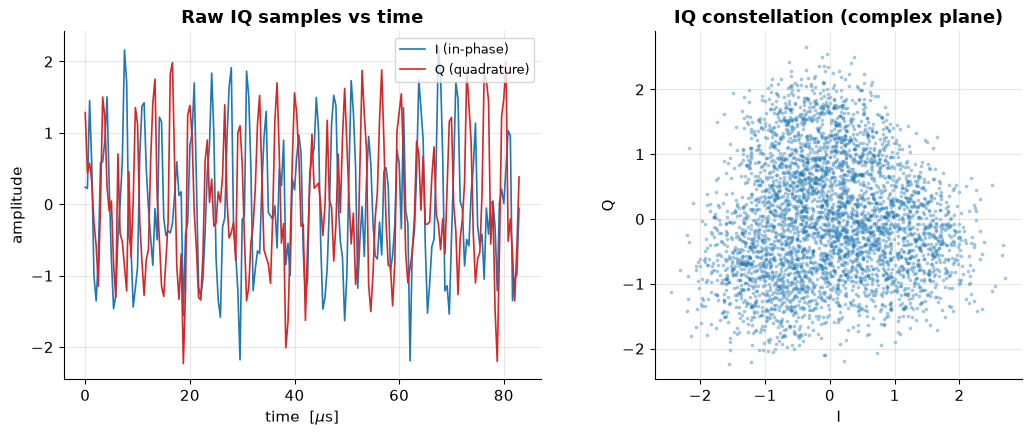

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

n_show = 200
ax1.plot(t[:n_show] * 1e6, iq[:n_show].real, color="#1f77b4", lw=1.2, label="I (in-phase)")
ax1.plot(t[:n_show] * 1e6, iq[:n_show].imag, color="#d62728", lw=1.2, label="Q (quadrature)")
ax1.set_xlabel("time  [$\\mu$s]")
ax1.set_ylabel("amplitude")
ax1.set_title("Raw IQ samples vs time")
ax1.legend(loc="upper right", fontsize=9)

ax2.scatter(iq[:4000].real, iq[:4000].imag, s=3, alpha=0.3, color="#1f77b4")
ax2.set_xlabel("I")
ax2.set_ylabel("Q")
ax2.set_title("IQ constellation (complex plane)")
ax2.set_aspect("equal")

fig.tight_layout()
plt.show()

## The power spectrum with Welch's method

Now the payoff: where is the signal in *frequency*? We hand the IQ stream to
`scipy.signal.welch`. Two details matter for IQ data:

- `return_onesided=False` — because the data is **complex**, the spectrum is
  genuinely two-sided (negative offsets are physically distinct from positive
  ones), so we keep the full $[-f_s/2,\,f_s/2]$ range.
- `fftshift` — `welch` returns frequencies wrapping around zero; we shift them so
  zero offset sits in the middle, then add the centre frequency to label the
  x-axis in real RF terms.

`nperseg` sets the segment length: longer segments give finer frequency resolution
($\Delta f = f_s/n_\mathrm{perseg}$) but average fewer of them, so the PSD is noisier.

In [4]:
nperseg = 4096
freqs, psd = sig.welch(
    iq,
    fs=fs,
    window="hann",
    nperseg=nperseg,
    noverlap=nperseg // 2,
    return_onesided=False,  # complex input -> keep the full two-sided spectrum
    scaling="density",
)

# welch returns frequencies 0..fs/2 then -fs/2..0; fftshift puts 0 in the middle.
freqs = np.fft.fftshift(freqs)
psd = np.fft.fftshift(psd)

psd_db = 10 * np.log10(psd)  # decibels relative to 1 unit/Hz
rf = fc + freqs  # absolute RF frequency of each bin

print(f"frequency resolution  Δf = fs/nperseg = {fs / nperseg / 1e3:.2f} kHz")
print(f"number of PSD bins        = {freqs.size}")

# Recover the tone offsets we injected, as a self-check.
peaks, _ = sig.find_peaks(psd_db, height=psd_db.mean() + 6, distance=20)
found = np.sort(freqs[peaks])
print("\\nrecovered tone offsets from the PSD peaks:")
for f_off in found:
    print(f"   {f_off / 1e3:+8.1f} kHz   (RF {(fc + f_off) / 1e9:.6f} GHz)")

frequency resolution  Δf = fs/nperseg = 0.59 kHz
number of PSD bins        = 4096
\nrecovered tone offsets from the PSD peaks:
     -300.0 kHz   (RF 1.420100 GHz)
     +250.2 kHz   (RF 1.420650 GHz)
     +600.0 kHz   (RF 1.421000 GHz)


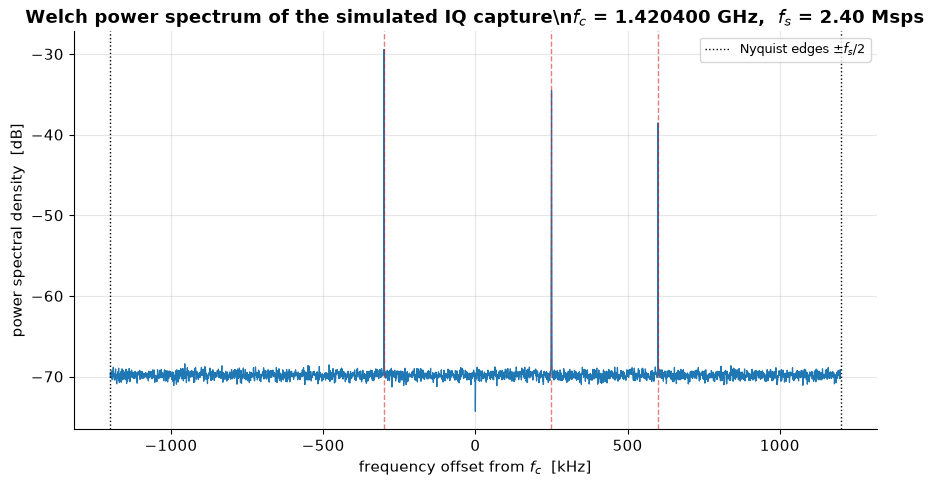

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot((rf - fc) / 1e3, psd_db, color="#1f77b4", lw=0.9)
ax.set_xlabel("frequency offset from $f_c$  [kHz]")
ax.set_ylabel("power spectral density  [dB]")
ax.set_title(
    f"Welch power spectrum of the simulated IQ capture\\n"
    f"$f_c$ = {fc / 1e9:.6f} GHz,  $f_s$ = {fs / 1e6:.2f} Msps"
)

# Mark the injected tone offsets.
for f_off in (-300e3, 250e3, 600e3):
    ax.axvline(f_off / 1e3, color="#d62728", ls="--", lw=1, alpha=0.6)

ax.axvline(-fs / 2 / 1e3, color="k", ls=":", lw=1)
ax.axvline(fs / 2 / 1e3, color="k", ls=":", lw=1, label="Nyquist edges $\\pm f_s/2$")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

Three sharp spikes rise out of the noise floor at exactly the offsets we injected
($-300$, $+250$, $+600$ kHz), and the peak-finder recovers them to the bin. The
dotted lines mark the **Nyquist edges** at $\pm f_s/2$: the whole observable world
of this capture lives between them. Everything outside is invisible — or worse,
**aliased** inside, which we demonstrate next.

## Sampling and aliasing, made visible

Aliasing is the most important pitfall in digital sampling, so let's see it
happen. We sample a single real sinusoid at a fixed rate $f_s$ and sweep its true
frequency from below to **above** the Nyquist frequency $f_s/2$. Beyond Nyquist,
the *apparent* frequency we measure folds back down — a high tone impersonates a
low one. This is precisely why real receivers filter the band before sampling.

In [6]:
fs_demo = 1000.0  # 1 kHz sample rate -> Nyquist = 500 Hz
n = 1024
nn = np.arange(n)

true_freqs = np.array([120.0, 300.0, 480.0, 700.0, 900.0])  # Hz; last two > Nyquist


def apparent_freq(f, fs):
    """Frequency a real tone of frequency f *appears* at after sampling at fs."""
    return np.abs(f - fs * np.round(f / fs))


print(f"sample rate fs = {fs_demo:.0f} Hz   ->   Nyquist = {fs_demo / 2:.0f} Hz\\n")
for f in true_freqs:
    fa = apparent_freq(f, fs_demo)
    tag = "ALIASED" if f > fs_demo / 2 else "ok"
    print(f"true {f:6.0f} Hz  ->  appears as {fa:6.0f} Hz   [{tag}]")

sample rate fs = 1000 Hz   ->   Nyquist = 500 Hz\n
true    120 Hz  ->  appears as    120 Hz   [ok]
true    300 Hz  ->  appears as    300 Hz   [ok]
true    480 Hz  ->  appears as    480 Hz   [ok]
true    700 Hz  ->  appears as    300 Hz   [ALIASED]
true    900 Hz  ->  appears as    100 Hz   [ALIASED]


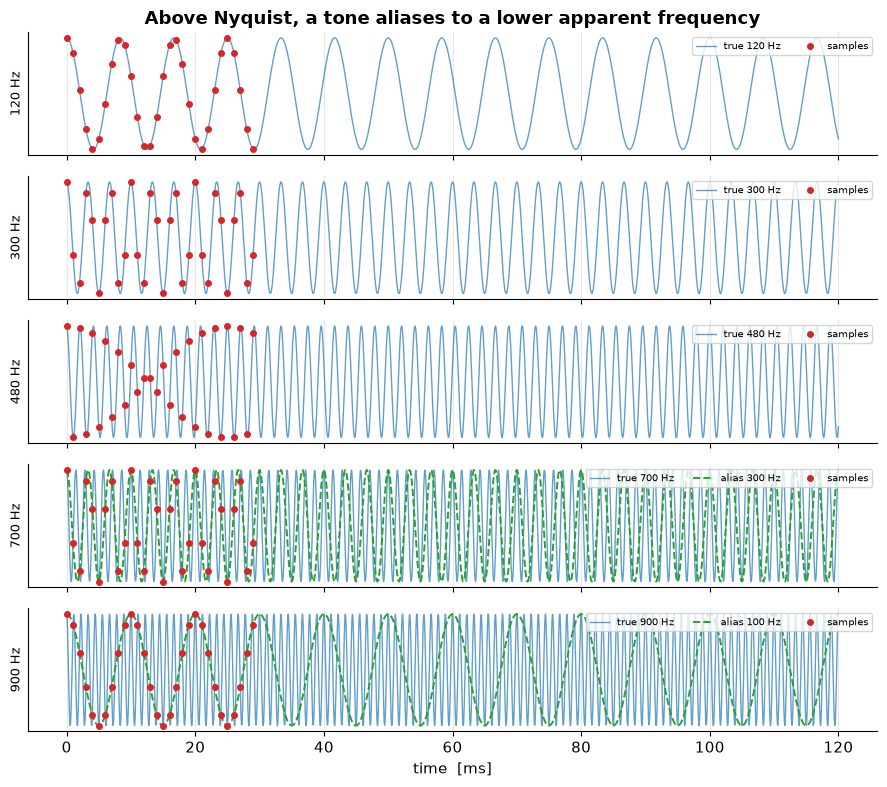

In [7]:
fig, axes = plt.subplots(len(true_freqs), 1, figsize=(9, 8), sharex=True)
t_cont = np.linspace(0, 4 / fs_demo * 30, 2000)  # a finely sampled "true" signal
t_samp = nn[:30] / fs_demo

for ax, f in zip(axes, true_freqs):
    fa = apparent_freq(f, fs_demo)
    ax.plot(
        t_cont * 1e3,
        np.cos(2 * np.pi * f * t_cont),
        color="#1f77b4",
        lw=1,
        alpha=0.7,
        label=f"true {f:.0f} Hz",
    )
    if fa != f:
        ax.plot(
            t_cont * 1e3,
            np.cos(2 * np.pi * fa * t_cont),
            color="#2ca02c",
            lw=1.4,
            ls="--",
            label=f"alias {fa:.0f} Hz",
        )
    ax.plot(
        t_samp * 1e3, np.cos(2 * np.pi * f * t_samp), "o", color="#d62728", ms=4, label="samples"
    )
    ax.set_ylabel(f"{f:.0f} Hz", fontsize=9)
    ax.legend(loc="upper right", fontsize=7, ncol=3)
    ax.set_yticks([])

axes[-1].set_xlabel("time  [ms]")
axes[0].set_title("Above Nyquist, a tone aliases to a lower apparent frequency")
fig.tight_layout()
plt.show()

For the 700 Hz and 900 Hz tones the red samples are *identical* to those a much
lower-frequency green sinusoid would produce: the sampler genuinely cannot tell
them apart. A 700 Hz tone reappears at $|700 - 1000| = 300$ Hz, and 900 Hz folds
to 100 Hz. With only the dots to go on, you would swear the signal was slow.
**This is aliasing**, and it is irreversible once it has happened — the only cure
is to filter out everything above $f_s/2$ *before* sampling.

## The waterfall: a spectrogram in time and frequency

A single PSD collapses the whole capture into one spectrum and throws away *when*
each signal was present. The **waterfall** (a spectrogram) keeps both axes: it
slices the capture into short windows, takes the spectrum of each, and stacks them
so you see frequency on one axis and time on the other. This is the live display
every SDR program shows, and it's how you spot a signal that switches on and off,
drifts, or sweeps.

To make the picture interesting we add a **chirp** — a tone that sweeps in
frequency — and a **burst** that appears only for part of the capture, on top of
the steady tones, then call `scipy.signal.spectrogram`.

In [8]:
# Reuse the steady tones, then add a frequency sweep and a timed burst.
iq_wf = iq.copy()
n_wf = iq_wf.size
t_wf = np.arange(n_wf) / fs

# A linear chirp sweeping from -500 kHz up to +500 kHz across the capture.
f0, f1 = -500e3, 500e3
inst_phase = 2 * np.pi * (f0 * t_wf + 0.5 * (f1 - f0) / t_wf[-1] * t_wf**2)
iq_wf += 0.5 * np.exp(1j * inst_phase)

# A burst at +800 kHz present only in the middle third of the capture.
burst = (t_wf > t_wf[-1] / 3) & (t_wf < 2 * t_wf[-1] / 3)
iq_wf[burst] += 0.7 * np.exp(1j * 2 * np.pi * 800e3 * t_wf[burst])

f_spec, t_spec, Sxx = sig.spectrogram(
    iq_wf,
    fs=fs,
    window="hann",
    nperseg=2048,
    noverlap=1024,
    return_onesided=False,
    scaling="density",
)
# Centre zero frequency for display.
f_spec = np.fft.fftshift(f_spec)
Sxx = np.fft.fftshift(Sxx, axes=0)
Sxx_db = 10 * np.log10(Sxx + 1e-12)

print(f"spectrogram shape (freq x time) = {Sxx.shape}")
print(f"time resolution  ≈ {(t_spec[1] - t_spec[0]) * 1e3:.3f} ms per column")
print(f"freq resolution  ≈ {fs / 2048 / 1e3:.2f} kHz per row")

spectrogram shape (freq x time) = (2048, 255)
time resolution  ≈ 0.427 ms per column
freq resolution  ≈ 1.17 kHz per row


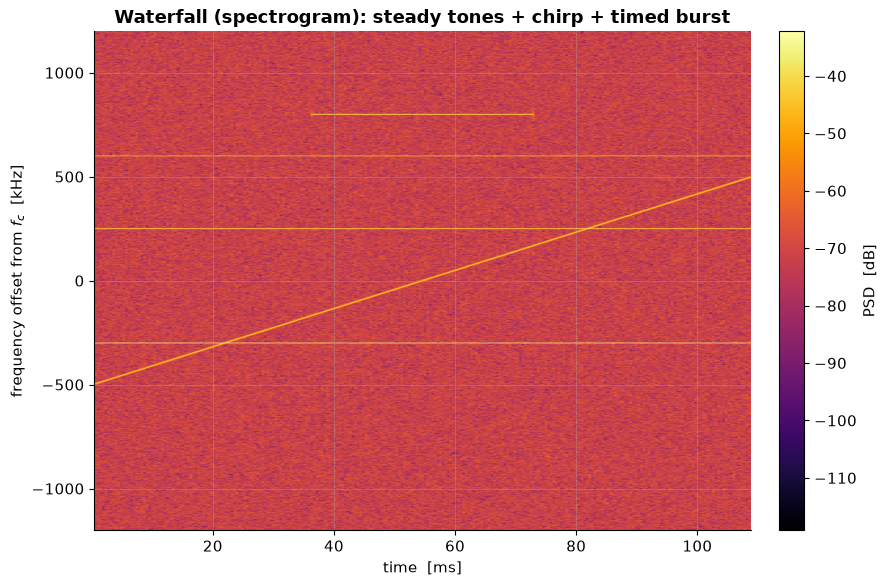

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
extent = [t_spec[0] * 1e3, t_spec[-1] * 1e3, f_spec[0] / 1e3, f_spec[-1] / 1e3]
im = ax.imshow(Sxx_db, aspect="auto", extent=extent, origin="lower", cmap="inferno")
ax.set_xlabel("time  [ms]")
ax.set_ylabel("frequency offset from $f_c$  [kHz]")
ax.set_title("Waterfall (spectrogram): steady tones + chirp + timed burst")
fig.colorbar(im, ax=ax, label="PSD  [dB]", fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

Read the waterfall like a score. The **horizontal stripes** are the steady tones —
constant in frequency, present for the whole capture. The **diagonal streak** is
the chirp sweeping from $-500$ to $+500$ kHz over time. And the **short bright bar**
near $+800$ kHz appears only in the middle third — exactly the burst we planted.
A plain PSD would have smeared all of these together; the spectrogram pulls them
apart in time. This is the single most useful diagnostic display in radio work.

## If you have an SDR: capturing real data

Everything above ran on simulated data so it works for everyone. If you *do* have
an RTL-SDR dongle, here is the shape of a real capture — guarded so that on the
base environment (or with no dongle plugged in) it silently falls back to the
simulated IQ. To run it for real you need the drivers from the
**GNU Radio container** (`containers/gnuradio.Dockerfile`), which installs
`rtl-sdr`, `gr-osmosdr`, and `pyrtlsdr`.

In [10]:
def capture_iq(center_freq=1.4204e9, sample_rate=2.4e6, n_samples=262144, gain="auto"):
    """Capture IQ from a real RTL-SDR if available; else return the simulation.

    Returns (iq, fs, fc, is_real).
    """
    if HAVE_RTLSDR:
        sdr = RtlSdr()
        try:
            sdr.sample_rate = sample_rate
            sdr.center_freq = center_freq
            sdr.gain = gain
            samples = sdr.read_samples(n_samples)  # complex64 IQ, already I+jQ
        finally:
            sdr.close()
        return np.asarray(samples), sample_rate, center_freq, True

    # --- Fallback: identical interface, simulated data ---------------------
    sim, _t, sim_fs, sim_fc = simulate_iq(
        n_samples=n_samples,
        sample_rate=sample_rate,
        center_freq=center_freq,
        generator=signals.rng(SEED),
    )
    return sim, sim_fs, sim_fc, False


iq_cap, fs_cap, fc_cap, is_real = capture_iq()
print(f"source: {'REAL RTL-SDR hardware' if is_real else 'SIMULATION (no hardware)'}")
print(f"got {iq_cap.size:,} IQ samples @ {fs_cap / 1e6:.2f} Msps, fc = {fc_cap / 1e9:.6f} GHz")

source: SIMULATION (no hardware)
got 262,144 IQ samples @ 2.40 Msps, fc = 1.420400 GHz


## Try it yourself

### TODO 1 — Tune the simulated centre frequency and tones

The `simulate_iq` helper takes `center_freq` and `tone_offsets`. Re-run the
simulation with a **different centre frequency** (say the FM broadcast band,
$f_c = 100$ MHz) and tones placed at offsets *you* choose, then recompute the
Welch PSD and confirm the peaks land where you put them.

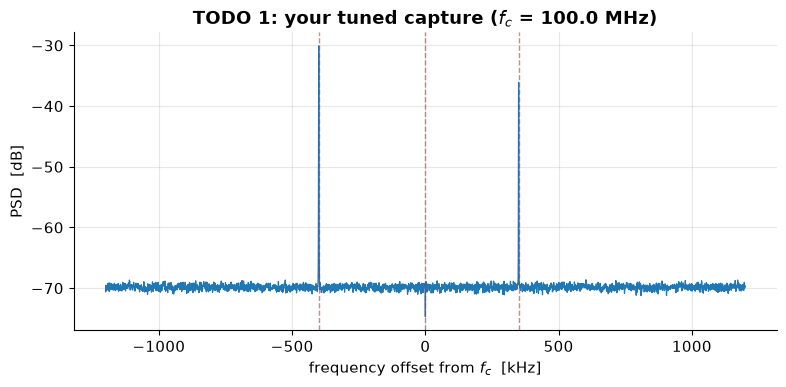

In [11]:
# TODO 1: change the centre frequency and tone offsets below to your own values,
#         then read off the PSD peaks. A working starter is filled in for you.

my_fc = 100e6  # TODO: pick your own centre freq
my_offsets = (-400e3, 0.0, 350e3)  # TODO: place your own tones
my_amps = (1.0, 0.8, 0.5)

my_iq, _my_t, my_fs, my_fc = simulate_iq(
    center_freq=my_fc,
    tone_offsets=my_offsets,
    tone_amps=my_amps,
    generator=signals.rng(7),
)
f, p = sig.welch(my_iq, fs=my_fs, nperseg=4096, return_onesided=False, scaling="density")
f = np.fft.fftshift(f)
p_db = np.fft.fftshift(10 * np.log10(p))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(f / 1e3, p_db, color="#1f77b4", lw=0.9)
for off in my_offsets:
    ax.axvline(off / 1e3, color="#d62728", ls="--", lw=1, alpha=0.6)
ax.set_xlabel("frequency offset from $f_c$  [kHz]")
ax.set_ylabel("PSD  [dB]")
ax.set_title(f"TODO 1: your tuned capture ($f_c$ = {my_fc / 1e6:.1f} MHz)")
fig.tight_layout()
plt.show()

# TODO: what happens if you place a tone at exactly +my_fs/2 (the Nyquist edge)? Try it.

<details><summary>Solution</summary>

Because `simulate_iq` places its tones as *offsets* from `center_freq`, the PSD is identical no matter what `center_freq` you choose — only the RF labels move — so the peaks always land exactly where you put the offsets. The Nyquist edge is the special case: an offset of $+f_s/2$ shares its DFT bin with $-f_s/2$, so the tone shows up at the *negative* edge instead.

```python
# Pick the FM broadcast band and your own tone offsets.
my_fc = 100e6                                  # 100 MHz centre frequency
my_offsets = (-600e3, 150e3, 500e3)            # tones you placed
my_amps = (1.0, 0.7, 0.4)

my_iq, _my_t, my_fs, my_fc = simulate_iq(
    center_freq=my_fc, tone_offsets=my_offsets, tone_amps=my_amps,
    generator=signals.rng(7),
)
f, p = sig.welch(my_iq, fs=my_fs, nperseg=4096, return_onesided=False, scaling="density")
f = np.fft.fftshift(f)
p_db = np.fft.fftshift(10 * np.log10(p))

# Confirm the peaks land at the offsets you chose (reuse the chapter's peak finder).
peaks, _ = sig.find_peaks(p_db, height=p_db.mean() + 6, distance=20)
print("recovered offsets [kHz]:", np.round(np.sort(f[peaks]) / 1e3, 1))
# -> [-600.   150.   499.8]   (matches my_offsets to the bin)

# Nyquist edge: put a single tone at exactly +my_fs/2.
edge_iq, *_ = simulate_iq(center_freq=my_fc, tone_offsets=(my_fs / 2,),
                          tone_amps=(1.0,), generator=signals.rng(7))
fe, pe = sig.welch(edge_iq, fs=my_fs, nperseg=4096, return_onesided=False, scaling="density")
fe = np.fft.fftshift(fe); pe_db = np.fft.fftshift(10 * np.log10(pe))
print("edge tone appears at [kHz]:", round(fe[np.argmax(pe_db)] / 1e3, 1))
# -> -1200.0, i.e. -my_fs/2: the +fs/2 and -fs/2 bins are the same one.
```

**Takeaway:** offsets, not the absolute centre frequency, set where signals appear in the PSD, so the recovered peaks reproduce your chosen offsets to the bin. The lone exception is $f_s/2$: it and $-f_s/2$ are a single bin, so a tone right at the Nyquist edge is ambiguous in sign and shows up at the opposite edge — the band is "open" at the top and "closed" at the bottom.

</details>

### TODO 2 — Capture (or simulate) and characterise a band

If you have an RTL-SDR, point it somewhere with real signal — the FM broadcast
band around 100 MHz is loud and easy. Use `capture_iq(center_freq=...)` above,
compute the Welch PSD, and identify the strongest station. **No hardware?** The
same call returns the simulation, so do the analysis on that instead: measure the
**noise floor** (median PSD) and the **signal-to-noise** of the brightest tone in
decibels.

In [12]:
# TODO 2: capture (or simulate) a band and characterise its noise floor + SNR.
#         A working starter is filled in; change center_freq / nperseg and extend it.

iq2, fs2, fc2, real = capture_iq(center_freq=100e6)  # FM band if you have a dongle
f2, p2 = sig.welch(iq2, fs=fs2, nperseg=8192, return_onesided=False, scaling="density")
p2_db = np.fft.fftshift(10 * np.log10(p2))

noise_floor = np.median(p2_db)  # robust estimate of the noise floor
peak = p2_db.max()
print(f"source       : {'REAL hardware' if real else 'SIMULATION'}")
print(f"noise floor  : {noise_floor:6.1f} dB   (median PSD)")
print(f"brightest bin: {peak:6.1f} dB")
print(f"peak SNR     : {peak - noise_floor:6.1f} dB")

# TODO: average several captures and watch the noise floor smooth out -- that is
#       the radiometer equation from Chapter 3, live. (Hint: stack PSDs and mean.)

source       : SIMULATION
noise floor  :  -69.8 dB   (median PSD)
brightest bin:  -26.4 dB
peak SNR     :   43.4 dB


<details><summary>Solution</summary>

The starter already measures the noise floor (median PSD) and peak SNR of one capture; the open question is the averaging hint. Stacking the PSDs of $K$ independent captures and taking the mean leaves the *level* of the noise floor unchanged but shrinks its scatter by $\sqrt{K}$ — the radiometer equation from [Chapter 3](03_signals_noise_radiometer.ipynb) in action.

```python
iq2, fs2, fc2, real = capture_iq(center_freq=100e6)
f2, p2 = sig.welch(iq2, fs=fs2, nperseg=8192, return_onesided=False, scaling="density")
p2_db = np.fft.fftshift(10 * np.log10(p2))

noise_floor = np.median(p2_db)
peak = p2_db.max()
print(f"source       : {'REAL hardware' if real else 'SIMULATION'}")
print(f"noise floor  : {noise_floor:6.1f} dB   (median PSD)")
print(f"peak SNR     : {peak - noise_floor:6.1f} dB")   # -> ~43.4 dB on the sim

# Average K captures: stack the *linear* PSDs, then convert to dB once.
# The simulated capture_iq is deterministic (fixed SEED), so to see the floor
# actually smooth on the base environment we draw an independent realisation each
# time with our own generator. With a real dongle every read is already fresh, so
# capture_iq(center_freq=100e6) inside the loop does the same job.
K = 16
psd_sum = None
for k in range(K):
    iqk, _tk, fsk, _ = simulate_iq(center_freq=100e6, generator=signals.rng(1000 + k))
    _, pk = sig.welch(iqk, fs=fsk, nperseg=8192, return_onesided=False, scaling="density")
    psd_sum = pk if psd_sum is None else psd_sum + pk
avg_db = np.fft.fftshift(10 * np.log10(psd_sum / K))

def floor_std(db):                       # scatter of the noise-floor bins only
    return db[db < np.median(db) + 3].std()

print(f"floor std, 1 capture  : {floor_std(p2_db):.2f} dB")
print(f"floor std, {K} averaged : {floor_std(avg_db):.2f} dB")  # ~sqrt(K) smaller
```

**Takeaway:** on the simulation the brightest tone sits about **43 dB** above a noise floor near $-70$ dB. Averaging $K=16$ independent captures drops the floor's scatter from roughly $0.57$ dB to $0.15$ dB (a factor of $\sim\!\sqrt{16}=4$) while the median floor stays put — exactly the $1/\sqrt{N}$ improvement in radiometric sensitivity, which is why real telescopes integrate. (The simulated `capture_iq` is seeded for reproducibility, so the loop re-seeds per draw to get independent realisations; a real dongle hands back fresh samples on every call automatically.)

</details>

## Recap

- A **software-defined radio** samples the radio voltage and does the rest in
  software. The cheap **RTL-SDR** dongle covers ≈24 MHz–1.7 GHz at up to a few
  Msps and is the gateway drug to digital radio astronomy.
- **Sampling** at rate $f_s$ can represent frequencies only up to the **Nyquist
  limit** $f_s/2$ (Shannon 1949); anything higher **aliases** back into the band —
  we watched a 700 Hz tone masquerade as 300 Hz.
- SDRs deliver **IQ (complex baseband) data** $z = I + jQ$, which captures a full
  bandwidth $f_s$ around the centre frequency and distinguishes positive from
  negative offsets.
- The **Welch periodogram** (`scipy.signal.welch`) turns IQ into a smooth **power
  spectrum**; the **spectrogram** (`scipy.signal.spectrogram`) keeps the time axis
  too, giving the **waterfall** display that makes transient and drifting signals
  obvious.
- Real capture lives behind a guarded `pyrtlsdr` import with the **GNU Radio
  container** (`containers/gnuradio.Dockerfile`) supplying the drivers — but the
  whole chapter runs on simulated IQ with no hardware at all.

## What's next

In **Chapter 6 — The Hydrogen Line** we point this machinery at the sky's most
famous radio signal: the 21 cm line of neutral hydrogen at 1420.405751 MHz — the
very frequency we centred our simulated capture on. With an SDR and a modest
antenna you can detect it yourself; in the base environment we'll simulate the
detection, fold in the radiometer equation from
[Chapter 3](03_signals_noise_radiometer.ipynb), and measure the line — the same
measurement that maps the rotation of the Galaxy in
[Chapter 11](11_hi_rotation_curve.ipynb).